# Synthetic Graph GRF Ablation

Ablation study on a synthetic graph with non-uniform degree distribution.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import gpytorch
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch

project_root = os.path.abspath('../..')
sys.path.append(project_root)
sys.path.append(os.path.abspath('.'))

from grf_gp.kernels.diffusion import DiffusionExactKernel
from grf_gp.kernels.general import GeneralGRFKernel
from grf_gp.model import ExactGraphGP, GRFGP
from grf_gp.sampler import GRFSampler
from grf_gp.utils.spectral import get_normalized_laplacian

from experiments.utils import evaluate_model, train_model
from grf_ablation_sampler import GRFAblationSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64

In [2]:
NUM_NODES = 900
ATTACHMENT_EDGES = 3
BETA_SAMPLE = 40.0
KERNEL_VARIANCE = 10.0
NOISE_STD = 0.1
TRAIN_FRACTION = 0.2
SEED = 1

WALKS_PER_NODE = 10_000
P_HALT = 0.01
MAX_WALK_LENGTH = 8

TRAIN_LR = 0.05
TRAIN_ITERS = 500

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_synthetic_graph(num_nodes, attachment_edges, seed):
    graph = nx.barabasi_albert_graph(num_nodes, attachment_edges, seed=seed)
    adjacency = nx.to_numpy_array(graph, dtype=np.float64)
    return graph, adjacency


def sample_diffusion_field(L, beta, sigma_f, noise_std, seed):
    torch.manual_seed(seed)
    cov = sigma_f ** 2 * torch.matrix_exp(-beta * L)
    jitter = 1e-6 * torch.eye(L.size(0), dtype=L.dtype, device=L.device)
    latent = torch.distributions.MultivariateNormal(
        loc=torch.zeros(L.size(0), dtype=L.dtype, device=L.device),
        covariance_matrix=cov + jitter,
    ).sample()
    noisy = latent + noise_std * torch.randn_like(latent)
    return latent, noisy


def fit_exact_diffusion(x_train, y_train, L):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    kernel = DiffusionExactKernel(L).to(device=device, dtype=dtype)
    model = ExactGraphGP(x_train, y_train, likelihood, kernel).to(device=device, dtype=dtype)
    train_model(model, likelihood, x_train, y_train, lr=TRAIN_LR, max_iter=TRAIN_ITERS, progress_desc='Exact diffusion')
    return model, likelihood, kernel


def fit_grf_model(x_train, y_train, rw_mats):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    kernel = GeneralGRFKernel(rw_mats, MAX_WALK_LENGTH).to(device=device, dtype=dtype)
    model = GRFGP(x_train, y_train, likelihood, kernel).to(device=device, dtype=dtype)
    train_model(model, likelihood, x_train, y_train, lr=TRAIN_LR, max_iter=TRAIN_ITERS, progress_desc='GeneralGRFKernel')
    return model, likelihood, kernel

In [4]:
graph, adjacency_matrix = make_synthetic_graph(NUM_NODES, ATTACHMENT_EDGES, SEED)
degrees = np.asarray(adjacency_matrix.sum(axis=1)).reshape(-1)
L_np = get_normalized_laplacian(adjacency_matrix)
L = torch.tensor(L_np, dtype=dtype, device=device)

latent_field, noisy_field = sample_diffusion_field(
    L=L,
    beta=BETA_SAMPLE,
    sigma_f=np.sqrt(KERNEL_VARIANCE),
    noise_std=NOISE_STD,
    seed=SEED,
)

all_idx = np.arange(NUM_NODES)
n_train = int(TRAIN_FRACTION * NUM_NODES)
train_idx = np.random.choice(NUM_NODES, size=n_train, replace=False)
test_idx = np.setdiff1d(all_idx, train_idx)

X_train = torch.tensor(train_idx, dtype=torch.long, device=device)
Y_train_raw = noisy_field[train_idx]
X_test = torch.tensor(test_idx, dtype=torch.long, device=device)
Y_test_raw = noisy_field[test_idx]

train_mean = Y_train_raw.mean()
train_std = Y_train_raw.std()
Y_train = ((Y_train_raw - train_mean) / train_std).flatten()
Y_test = ((Y_test_raw - train_mean) / train_std).flatten()

print(f'num_nodes: {NUM_NODES}')
print(f'num_edges: {graph.number_of_edges()}')
print(f'degree min/mean/max: {degrees.min():.1f} / {degrees.mean():.2f} / {degrees.max():.1f}')
print(f'n_train: {len(train_idx)} | n_test: {len(test_idx)}')
print(f'train mean/std: {train_mean.item():.4f} / {train_std.item():.4f}')

num_nodes: 900
num_edges: 2691
degree min/mean/max: 1.0 / 5.98 / 88.0
n_train: 180 | n_test: 720
train mean/std: -0.0372 / 0.0981


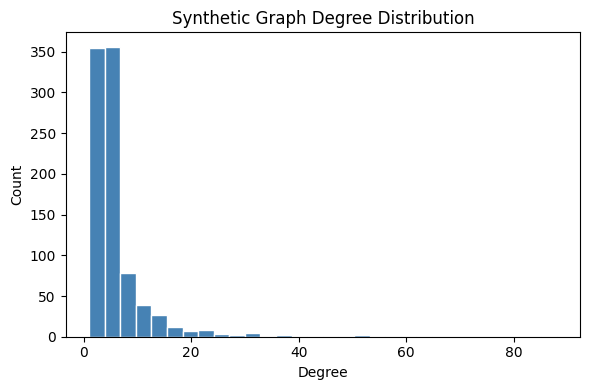

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Synthetic Graph Degree Distribution')
plt.tight_layout()
plt.show()

## Random-Walk Features

In [6]:
sampler = GRFSampler(
    L,
    walks_per_node=WALKS_PER_NODE,
    p_halt=P_HALT,
    max_walk_length=MAX_WALK_LENGTH,
    seed=SEED,
    use_tqdm=True,
    n_processes=4,
)
rw_mats = sampler()

ablation_sampler = GRFAblationSampler(
    L,
    walks_per_node=WALKS_PER_NODE,
    p_halt=P_HALT,
    max_walk_length=MAX_WALK_LENGTH,
    seed=SEED,
    use_tqdm=True,
    n_processes=4,
)
rw_mats_ablation = ablation_sampler()

/Users/matthew/Documents/Efficient Gaussian Process on Graphs/Efficient_Gaussian_Process_On_Graphs/venv/lib/python3.11/site-packages/grf_gp/utils/csr.py:17: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  return adjacency.to_sparse_csr()


## Exact Diffusion

In [7]:
exact_model, exact_likelihood, exact_kernel = fit_exact_diffusion(X_train, Y_train, L)
lml_exact, rmse_exact, nlpd_exact = evaluate_model(
    exact_model,
    exact_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
print(f'Exact diffusion | LML: {lml_exact:.4f} | RMSE: {rmse_exact:.4f} | NLPD: {nlpd_exact:.4f}')
print(f'beta: {exact_kernel.beta.item():.4f} | sigma_f: {exact_kernel.sigma_f.item():.4f}')

Exact diffusion:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/matthew/Documents/Efficient Gaussian Process on Graphs/Efficient_Gaussian_Process_On_Graphs/venv/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Exact diffusion | LML: -245.2564 | RMSE: 0.1014 | NLPD: 1.4535
beta: 0.7671 | sigma_f: 0.3365


## Learned GRF

In [9]:
grf_model, grf_likelihood, grf_kernel = fit_grf_model(X_train, Y_train, rw_mats)
lml_grf, rmse_grf, nlpd_grf = evaluate_model(
    grf_model,
    grf_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
print(f'Learned GRF | LML: {lml_grf:.4f} | RMSE: {rmse_grf:.4f} | NLPD: {nlpd_grf:.4f}')
print('modulation:', grf_kernel.modulation_function.detach().cpu().numpy())

GeneralGRFKernel:   0%|          | 0/500 [00:00<?, ?it/s]

Learned GRF | LML: -150.0180 | RMSE: 0.1017 | NLPD: 1.6421
modulation: [-0.43188126 -0.60903629 -0.02846283  0.20818714  0.00414953 -0.00650689
  0.00912646  0.0049292 ]


## Ablated GRF

In [8]:
abl_model, abl_likelihood, abl_kernel = fit_grf_model(X_train, Y_train, rw_mats_ablation)
lml_abl, rmse_abl, nlpd_abl = evaluate_model(
    abl_model,
    abl_likelihood,
    X_train,
    Y_train,
    X_test,
    Y_test,
    train_std,
)
print(f'Ablated GRF | LML: {lml_abl:.4f} | RMSE: {rmse_abl:.4f} | NLPD: {nlpd_abl:.4f}')
print('modulation:', abl_kernel.modulation_function.detach().cpu().numpy())

GeneralGRFKernel:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/matthew/Documents/Efficient Gaussian Process on Graphs/Efficient_Gaussian_Process_On_Graphs/venv/lib/python3.11/site-packages/linear_operator/utils/sparse.py:51: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if nonzero_indices.storage():
/Users/matthew/Documents/Efficient Gaussian Process on Graphs/Efficient_Gaussian_Process_On_Graphs/venv/lib/python3.11/site-packages/linear_operator/utils/sparse.py:66: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:656.)
  res = cls(index_tensor, value_tensor, interp_size)


Ablated GRF | LML: -223.6493 | RMSE: 0.1014 | NLPD: 4.2868
modulation: [ -0.61608495   3.96697106   1.85728407  -0.1027309   -8.77876303
 -17.68766795 -18.39483981 -19.9980275 ]


In [10]:
pd.DataFrame(
    [
        {'model': 'Exact diffusion', 'lml': lml_exact, 'rmse': rmse_exact, 'nlpd': nlpd_exact},
        {'model': 'Learned GRF', 'lml': lml_grf, 'rmse': rmse_grf, 'nlpd': nlpd_grf},
        {'model': 'Ablated GRF', 'lml': lml_abl, 'rmse': rmse_abl, 'nlpd': nlpd_abl},
    ]
).round(4)

,model,lml,rmse,nlpd
0,Exact diffusion,-245.2564,0.1014,1.4535
1,Learned GRF,-150.0180,0.1017,1.6421
2,Ablated GRF,-223.6493,0.1014,4.2868
